# B3 · Transformer Attention Mechanism

Scaled dot-product attention implemented from scratch and optimised in three steps
(topic **B3** of the project catalog).

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | PyTorch on CPU | correctness reference + timing baseline |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles; (max, sum) in a single pass via log-sum-exp |
| `GpuV3` | FlashAttention-style fused kernel | tile Q, K, V together; the N×N score matrix never exists in global memory |

Following the *partial GPU principle*, everything except attention — embedding,
projections, layer norms, FFN — stays in PyTorch on the CPU. Only the profiled
bottleneck is replaced.

In [2]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

`CpuPipeline` runs the whole block in PyTorch, with every step wrapped in
`torch.profiler.record_function`. Attention is $O(N^2 D)$ compute and $O(N^2)$
memory while every other step is linear in $N$, so its share of a forward pass
grows quadratically: ~10% at $N = 128$, drawing level with the FFN around
$N = d_{ff} = 2048$ and overtaking everything beyond, as the chart confirms.
Long sequences are exactly where the bottleneck lives — which is why attention,
and only attention, is the GPU target.

In [3]:
# Correctness gate: the baseline must match torch's SDPA before it can serve as reference.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    torch.testing.assert_close(cpu_model(x), bench.sdpa_reference(cpu_model, x))
print("CpuPipeline matches torch.nn.functional.scaled_dot_product_attention")

CpuPipeline matches torch.nn.functional.scaled_dot_product_attention


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-20 14:45:07 415318:415318 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-

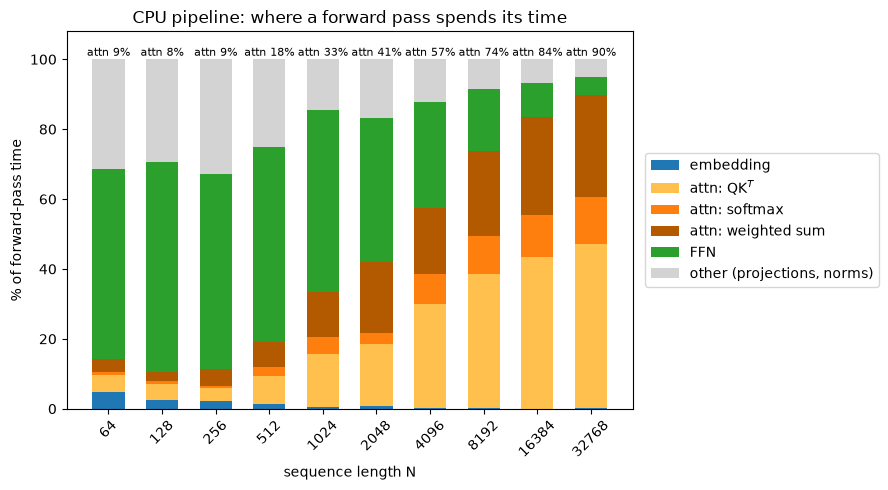

In [4]:
# Chart 1 -- share of forward-pass time per step (CPU pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 16)]
pcts = [bench.step_percentages(cpu_model, n) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("CPU pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

**V1 — naive three-kernel** (`gpu_v1.py`): `_matmul` (QK$^T$), `_scale`,
`_softmax`, `_matmul` (weights·V) — four launches, and every intermediate
including the full N×N score matrix round-trips through global memory.
The matmul loads are coalesced (adjacent threads read adjacent addresses) but
nothing is reused, and the softmax — one thread per row, three reads of the
row — is fully uncoalesced; V2's block-per-row softmax fixes both.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from global
memory 16× less often; shared arrays are padded to dodge bank conflicts) and fuses
the $1/\sqrt{D}$ scaling into the epilogue. `_softmax_online` uses one block
per row: a running (max, sum) pair rescaled when the max moves — the
log-sum-exp trick — gets both out of **one** coalesced read of the row.

**V3 — FlashAttention-style fused kernel** (`gpu_v3.py`): a single kernel,
one **warp per four query rows** (8 warps per block). K/V tiles live in
shared memory and are reused by all 32 rows of the block; the query rows and
output accumulators are split across the 32 lanes' registers, register-tiled
so that **each K/V element fetched from shared memory feeds four FMAs** — no
N×N intermediate exists anywhere. Dot products are reduced with warp shuffles
(`shfl_xor_sync` butterfly), and the softmax runs online while the weighted
sum accumulates. Extra memory drops from $O(N^2)$ to $O(N)$.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [5]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2, GpuV3):
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV1: matches torch SDPA within 1e-4
GpuV2: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV3: matches torch SDPA within 1e-4


## Benchmark — attention step time

Timings are for the attention step only, on precomputed q, k, v — and they
*include* the CPU→GPU and GPU→CPU transfers, because that is the true cost of
swapping a kernel into an otherwise-CPU pipeline. Sequence lengths sweep the
powers of two from $2^6$ to $2^{15}$ (64 → 32768), passing through the spec's
128 / 512 / 2048 checkpoints on the way.

Keep in mind the bar: the "CPU" attention step is torch's multithreaded
MKL/BLAS matmul, not a naive loop. A naive kernel with coalesced
matmuls (V1) roughly ties it (and loses outright to a many-core server CPU) —
the real wins come from data reuse (V2) and fusion (V3).

In [ ]:
SEQ_LENS = [2 ** x for x in range(6, 16)]

if cuda.is_available():
    classes = {"CPU": CpuPipeline,
               "V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               "V3 flash fused": GpuV3}
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    times["torch SDPA (GPU)"] = [bench.sdpa_gpu_ms(cpu_model, n, reps=3) for n in SEQ_LENS]

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"V1 naive": "tab:blue", "V2 tiled + online softmax": "tab:orange",
          "V3 flash fused": "tab:green", "torch SDPA (GPU)": "gray"}

## Attention kernel throughput — TFLOP/s and bandwidth utilisation

How close do the kernels get to the hardware limits? Following the HW02
roofline methodology: **device-resident timing with CUDA events** (no
transfers in the timed region), FLOPs counted from the algorithm, and a
dominant-term **global-memory traffic model** per version.

- **FLOPs**: two N×N×D matmuls plus the softmax ≈ $4N^2D + 5N^2$
- **Traffic** (fp32 = 4 B/element):

| version | bytes moved | why |
|---|---|---|
| V1 naive | $4\,(4N^2D + 6N^2)$ | matmul operands re-read from global memory per output element |
| V2 tiled | $4\,(4N^2D/16 + 4N^2)$ | shared-memory tiles: each operand element read once per 16-tile |
| V3 flash | $4\,(N^2D/16 + 2ND)$ | K/V streamed once per 32-row block; no N×N intermediate at all |

Arithmetic intensity is the whole story of V1→V3: ≈0.25 FLOP/B (naive) →
≈4 (tiled) → ≈16 (flash) — each step climbs the roofline by increasing data
reuse. torch SDPA appears in the TFLOP/s chart as the reference; its internal
traffic is not ours to model, so it is left out of the utilisation chart.

Note the models count **requested** bytes. V1 requests the same K/V elements
from thousands of threads and the L1/L2 caches serve most of that redundancy,
so its requested-traffic rate can sit *above* the physical DRAM peak. V2 and
V3 eliminate redundant requests, so their curves reflect genuine DRAM
pressure.

In [8]:
# Kernel-only timing sweep (CUDA events, device-resident) + hardware peaks
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs | "
          f"peak {specs['tflops']:.1f} TFLOP/s fp32 | peak {specs['bw_gbs']:.0f} GB/s")

    D_MODEL = 512
    FLOPS = lambda n: 4 * n * n * D_MODEL + 5 * n * n
    TRAFFIC = {  # bytes of global-memory traffic (dominant terms, fp32 = 4 B)
        "V1 naive": lambda n: 4 * (4 * n * n * D_MODEL + 6 * n * n),
        "V2 tiled + online softmax": lambda n: 4 * (4 * n * n * D_MODEL / 16 + 4 * n * n),
        "V3 flash fused": lambda n: 4 * (n * n * D_MODEL / 16 + 2 * n * D_MODEL),
    }

    kmodels = {"V1 naive": GpuV1().eval(),
               "V2 tiled + online softmax": GpuV2().eval(),
               "V3 flash fused": GpuV3().eval()}
    REPS = lambda n: 10 if n <= 4096 else 3  # HW01 uses 10; large N costs seconds
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=REPS(n)) for n in SEQ_LENS]
              for name, m in kmodels.items()}
    ktimes["torch SDPA (GPU)"] = [bench.sdpa_kernel_ms(cpu_model, n, reps=REPS(n))
                                  for n in SEQ_LENS]

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: NVIDIA L4 | 58 SMs | peak 30.3 TFLOP/s fp32 | peak 300 GB/s

     N                      V1 naive     V2 tiled + online softmax                V3 flash fused              torch SDPA (GPU)   (kernel-only ms)
------------------------------------------------------------------------------------------------------------------------------
    64                      1.685 ms                      1.349 ms                      0.717 ms                      0.229 ms
   128                      1.603 ms                      1.301 ms                      0.680 ms                      0.217 ms
   256                      1.743 ms                      1.306 ms                      0.687 ms                      0.163 ms
   512                      1.619 ms                      1.313 ms                      0.838 ms                      0.172 ms
  1024                      4.621 ms                      1.458 ms                      1.514 ms                      0.235 ms
  2048                    

### Transfer cost — compute-only vs with-transfer (HW01 stage-5 analysis)

The end-to-end benchmark pays the CPU→GPU→CPU copy on every call; the kernel
sweep does not. Their difference is the price of swapping a GPU kernel into a
CPU pipeline: it grows O(N) while compute grows O(N²), so it dominates at
small N and amortises at large N.

In [9]:
if cuda.is_available():
    name = "V3 flash fused"
    print(f"{'N':>6} {'with transfer':>14} {'kernel only':>12} {'overhead':>10} {'share':>7}")
    for i, n in enumerate(SEQ_LENS):
        e2e, kern = times[name][i], ktimes[name][i]
        over = max(e2e - kern, 0.0)
        print(f"{n:>6} {e2e:>11.2f} ms {kern:>9.3f} ms {over:>7.2f} ms {over / e2e * 100:>6.0f}%")
    moved = 16 * SEQ_LENS[-1] * 512  # q,k,v up + out down, fp32 bytes
    over = max(times[name][-1] - ktimes[name][-1], 1e-9)
    print(f"\nAt N={SEQ_LENS[-1]}: {moved / 1e6:.0f} MB moved -> "
          f"~{moved / (over / 1e3) / 1e9:.1f} GB/s effective transfer rate")

     N  with transfer  kernel only   overhead   share
    64        1.32 ms     0.717 ms    0.60 ms     46%
   128        1.42 ms     0.680 ms    0.74 ms     52%
   256        1.93 ms     0.687 ms    1.24 ms     64%
   512        3.69 ms     0.838 ms    2.85 ms     77%
  1024        4.44 ms     1.514 ms    2.92 ms     66%
  2048       10.49 ms     5.453 ms    5.04 ms     48%
  4096       25.42 ms    17.387 ms    8.04 ms     32%
  8192       78.23 ms    61.803 ms   16.43 ms     21%
 16384      292.30 ms   239.050 ms   53.26 ms     18%
 32768     1109.32 ms   983.791 ms  125.53 ms     11%

At N=32768: 268 MB moved -> ~2.1 GB/s effective transfer rate


In [ ]:
# Chart 2 -- attention step time: with transfer vs kernel only
if cuda.is_available():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, (title, data) in zip(axes, [("with transfer (end-to-end)", times),
                                        ("kernel only (CUDA events)", ktimes)]):
        for name, ts in data.items():
            if name == "CPU":
                continue
            ax.plot(SEQ_LENS, ts, marker="o", color=COLORS[name],
                    linestyle="--" if "SDPA" in name else "-", label=name)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, which="both", alpha=0.3)
    axes[0].set_ylabel("attention step time (ms)")
    axes[0].legend()
    plt.suptitle("Transfer overhead: dominant at small N, amortised at large N")
    plt.tight_layout()
    plt.show()

In [ ]:
# Chart 3 -- speedup over the CPU attention step: with transfer vs kernel only
if cuda.is_available():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, (title, data) in zip(axes, [("with transfer (end-to-end)", times),
                                        ("kernel only (CUDA events)", ktimes)]):
        for name, ts in data.items():
            if name == "CPU":
                continue
            speedups = [c / t for c, t in zip(times["CPU"], ts)]
            ax.plot(SEQ_LENS, speedups, marker="o", color=COLORS[name],
                    linestyle="--" if "SDPA" in name else "-", label=name)
        ax.axhline(1.0, color="black", linewidth=0.8, linestyle=":")
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, which="both", alpha=0.3)
    axes[0].set_ylabel("speedup over CPU attention (x)")
    axes[0].legend()
    plt.suptitle("Attention speedup vs CPU baseline (CPU compute time in both panels)")
    plt.tight_layout()
    plt.show()

In [ ]:
# Chart 4 -- effective TFLOP/s per kernel
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, ts in ktimes.items():
        tflops = [FLOPS(n) / (t / 1e3) / 1e12 for n, t in zip(SEQ_LENS, ts)]
        ax.plot(SEQ_LENS, tflops, marker="o", color=COLORS[name],
                linestyle="--" if "SDPA" in name else "-",
                label=f"{name}  ({tflops[-1]:.2f} TFLOP/s at N={SEQ_LENS[-1]})")
    ax.axhline(specs["tflops"], color="black", linestyle=":", linewidth=1,
               label=f"peak fp32 ({specs['tflops']:.0f} TFLOP/s)")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("effective TFLOP/s")
    ax.set_title("Attention kernel throughput")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Chart 5 -- effective global-memory throughput vs the DRAM ceiling
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, traffic in TRAFFIC.items():
        gbs = [traffic(n) / (t / 1e3) / 1e9 for n, t in zip(SEQ_LENS, ktimes[name])]
        pct = gbs[-1] / specs["bw_gbs"] * 100
        ax.plot(SEQ_LENS, gbs, marker="o", color=COLORS[name],
                label=f"{name}  ({pct:.0f}% of peak at N={SEQ_LENS[-1]})")
    ax.axhline(specs["bw_gbs"], color="black", linestyle=":", linewidth=1,
               label=f"peak DRAM bandwidth ({specs['bw_gbs']:.0f} GB/s)")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("requested global traffic / time (GB/s)")
    ax.set_title("Memory bandwidth utilisation (requested traffic vs DRAM peak)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()